In [1]:
# Input take label, latent semantics and k
LABEL_INPUT = input(
"""
Provide the label for which you want to find most similar images
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd" if you generated it for tasks where you didn't select the algorithm,
use this format "LS3_color"
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most similar images to find under the latent space."))

In [27]:
LATENT_SEMANTICS = "LS4_fc_svd"
K = 10
LABEL_INPUT = "airplanes"

In [28]:
from utils.database_utils import retrieve
from utils.distance_utils import top_k_distance_ranker
from utils.database_utils import compressed_retrieve
from scipy.spatial.distance import cityblock, correlation, cosine, euclidean
from feature_models.feature_matrix.label_label_similarity import LabelLabelSimilarity

In [29]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

Files already downloaded and verified


In [30]:
LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]
FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

# Load created latent space
reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

In [31]:
def find_nearest_cluster(vector, query_vector, K, distance_fn = euclidean):
    distance = []
    for i, feature_item in enumerate(vector.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        current_vector = feature_tuple[1]
        distance.append((image_id, distance_fn(query_vector, current_vector)))
    distance.sort(key=lambda x:x[1])
    return distance[:K]

In [32]:
def get_distances_for_image_latent_space(latent_space):
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        feature = latent_space[i]
        centroid_format_latent_space[image_id] = (label, feature)

    # Find centroids for the labels
    from utils.vector_utils import get_representative_vectors_for_labels
    from utils.dataset_utils import initialize_dataset

    centroids = get_representative_vectors_for_labels(centroid_format_latent_space, initialize_dataset().categories, 1)

    # Find closest labels based on distance
    distances = find_nearest_cluster(centroid_format_latent_space, centroids[LABEL_INPUT], K)
    return distances

In [33]:
if LATENT_SPACE == "LS1":
    # For LS1 find labels for every image in the latent space
    print("LS1")
    latent_space = reducer.reduce_features(feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS2":
    # For LS2 find labels for every image in the latent space
    print("LS2")
    latent_space = reducer.image_latent_space_weights
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS3":
    # For LS3
    print("LS3")
    pass
else:
    print("LS4")
    image_feature_vectors = compressed_retrieve(f'img_img_{FEATURE_SPACE}.pt')
    latent_space = reducer.reduce_features(image_feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

LS4
Files already downloaded and verified


      img_id      label                                             vector
0         0      Faces  [7.137020681043016, 9.078978899534974, 0.03725...
1         2      Faces  [3.494235773456006, 5.459957493527282, 0.46352...
2         4      Faces  [7.50995963144455, 10.419560020046612, 0.12842...
3         6      Faces  [6.5907014039417025, 9.89513326875736, 0.11503...
4         8      Faces  [8.05066982845258, 10.99901982077524, 0.391204...
..      ...        ...                                                ...
995    1990  airplanes  [8.418533364847287, -4.722161058373683, -1.885...
996    1992  airplanes  [8.937756777901203, -5.453907521132141, -6.360...
997    1994  airplanes  [9.38641816885448, -5.3517810018236815, -5.442...
998    1996  airplanes  [8.391546801956382, -5.7351166646849405, -2.97...
999    1998  airplanes  [8.647749677734247, -6.382786761504529, -5.665...

[1000 rows x 3 columns] 


[(2436, 0.8373708868374932), (2278, 0.9

Image Id: 2436 

Distance Score: 0.8373708868374932


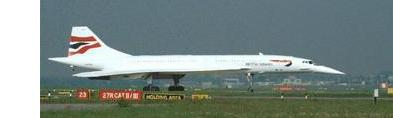

Image Id: 2278 

Distance Score: 0.9010173026659343


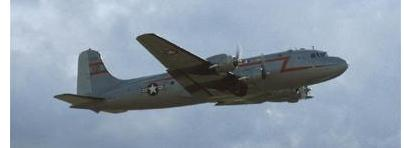

Image Id: 2104 

Distance Score: 1.0022217201225694


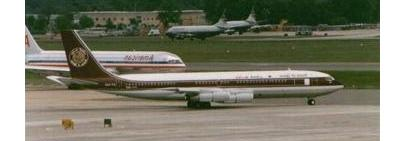

Image Id: 2706 

Distance Score: 1.0896214238408939


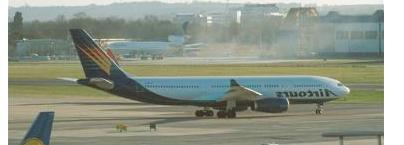

Image Id: 2318 

Distance Score: 1.1730900643312778


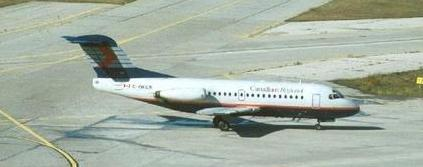

Image Id: 2168 

Distance Score: 1.2197609996797412


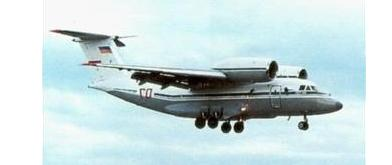

Image Id: 2346 

Distance Score: 1.239494280563007


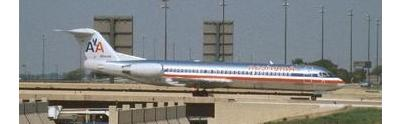

Image Id: 2546 

Distance Score: 1.2526162327890307


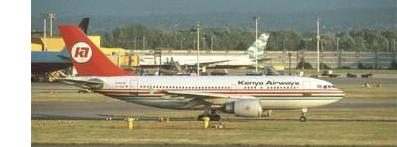

Image Id: 2322 

Distance Score: 1.2537632538511447


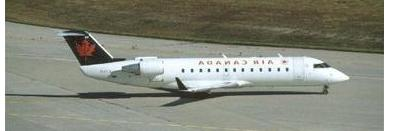

Image Id: 2016 

Distance Score: 1.269145714891391


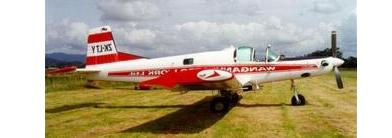

In [34]:
for i in range(len(distances)):
    image_id = distances[i][0]
    distance = distances[i][1]
    print("Image Id:", image_id, "\n\nDistance Score:", distance)
    display(dataset[image_id][0])